# Exercise 4 | TKO_7092 Evaluation of Machine Learning Methods
---

Student name<br> Shaktiman Choudhury<br>
Student number<br> 2512876 <br>
Student email<br> shchou@utu.fi<br>

---

The deadline for returning this exercise is **25.2.2026**.

If you have any questions about this exercise, please contact Riikka Numminen (rimanu@utu.fi) in good time before the deadline.

## Nested cross-validation for feature selection
In this exercise, the task is to use leave-one-out cross-validation for model selection to understand the effect of the winner's curse. 
This is demonstrated by using greedy forward selection and a random binary data set.
The data set is a balanced sample of size 60 (i.e. 30 positives and 30 negatives) with a hundred features. The data are i.i.d., and every feature follows a Bernoulli distribution with $p=0.5$. Thus, there is no signal in the data. 

The model to be used is 1-nearest neighbour with 10 features, and the greedy forward selection is used to select the best 10 features among all the features.
Leave-one-out cross-validation is used for performance evaluation, and the prediction performance is measured as accuracy. 

### Greedy forward feature selection
Greedy forward feature selection is an iterative feature selection process, where the features are selected one by one, avoiding a need to iterate through every possible combination of features. The features are selected as follows:
- First, every feature is tested solely and the best is selected.
- Then the selected feature is tested together with any other remaining feature and the best such a set of two features is selected.
- Then that set of the selected two features is tested together with any other remaining feature and the best set of three features is selected.
- The process is then continued accordingly until the desired amount of features is selected.

### Implement the following tasks to complete this exercise:
1. Use leave-one-out cross-validation to select the best 10 features. Report the optimal set of features and the corresponding accuracy.
2. Use nested leave-one-out cross-validation (leave-one-out on both layers of cross-validation) to obtain an estimate of the prediction accuracy on unseen data, when the final hypotheses are obtained according to the procedure in the first step.
3. Explain the difference in the obtained accuracies.

### Import libraries

In [1]:
# In this cell, import all the libraries that you will use in this notebook. For example:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import LeaveOneOut 
import time

### Load the data
The labels are saved in a file *y_generated.csv*, and the features in file *X_generated.csv*.

In [2]:
# Read the data files. Verify that the data dimensions are as expected.
X = pd.read_csv('X_generated.csv', header=None).values
y = pd.read_csv('y_generated.csv', header=None).values.flatten()

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

print(f"Unique classes in y: {np.bincount(y)}")

Shape of X: (60, 100)
Shape of y: (60,)
Unique classes in y: [30 30]


### Leave-one-out cross-validation

In [ ]:
# Write your implementation for the first part of the exercise here.
def greedy_forward_selection(X_data, y_data, n_to_select=10):
    selected = []
    remaining = list(range(X_data.shape[1]))
    loo = LeaveOneOut()
    knn = KNeighborsClassifier(n_neighbors=1)
    best_feat = 0
    best_acc = 0
    
    for _ in range(n_to_select):
        best_feat, best_acc = -1, -1
        
        for feat in remaining:
            current_set = selected + [feat]
            y_preds = []
            
            for train_idx, test_idx in loo.split(X_data):
                knn.fit(X_data[train_idx][:, current_set], y_data[train_idx])
                y_preds.append(knn.predict(X_data[test_idx][:, current_set])[0])
            
            acc = accuracy_score(y_data, y_preds)
            if acc > best_acc:
                best_acc, best_feat = acc, feat
        
        selected.append(best_feat)
        remaining.remove(best_feat)
    return selected, best_acc


start_time = time.time()
opt_features, opt_accuracy = greedy_forward_selection(X, y, 10)
end_time = time.time()

step1_duration = end_time - start_time
print(f"LOOCV took {step1_duration:.2f} seconds.")
print(f"Estimated time for Step 2: {(step1_duration * 60) / 60:.2f} minutes.")

print(f"Selected feature {opt_features} with accuracy {opt_accuracy:.4f}")


LOOCV took 51.38 seconds.
Estimated time for Step 2: 51.38 minutes.
Selected feature [0, 1, 94, 65, 6, 64, 73, 55, 24, 35] with accuracy 0.8333


### Nested leave-one-out cross-validation

In [ ]:
loo_outer = LeaveOneOut()
outer_predictions = []

start_nested_time = time.time()
for i, (train_idx, test_idx) in enumerate(loo_outer.split(X)):
    features_found, _ = greedy_forward_selection(X[train_idx], y[train_idx], 10)
    
    knn = KNeighborsClassifier(n_neighbors=1)
    knn.fit(X[train_idx][:, features_found], y[train_idx])
    pred = knn.predict(X[test_idx][:, features_found])
    
    outer_predictions.append(pred[0] == y[test_idx][0])
    
    # Progress check
    if (i + 1) % 5 == 0:
        elapsed = time.time() - start_nested_time
        avg_time = elapsed / (i + 1)
        remaining_time = avg_time * (60 - (i + 1))
        print(f"Iteration {i+1}/60 completed | Elapsed: {elapsed/60:.1f}m | ETA: {remaining_time/60:.1f}m")
nested_accuracy = np.mean(outer_predictions)
print(f"\nFinal Nested LOOCV Accuracy: {nested_accuracy:.4f}")

Iteration 5/60 completed | Elapsed: 3.9m | ETA: 42.4m
Iteration 10/60 completed | Elapsed: 7.6m | ETA: 38.2m
Iteration 15/60 completed | Elapsed: 11.5m | ETA: 34.6m
Iteration 20/60 completed | Elapsed: 15.4m | ETA: 30.7m
Iteration 25/60 completed | Elapsed: 19.2m | ETA: 26.9m
Iteration 30/60 completed | Elapsed: 23.0m | ETA: 23.0m
Iteration 35/60 completed | Elapsed: 26.8m | ETA: 19.2m
Iteration 40/60 completed | Elapsed: 30.7m | ETA: 15.3m
Iteration 45/60 completed | Elapsed: 34.5m | ETA: 11.5m
Iteration 50/60 completed | Elapsed: 38.3m | ETA: 7.7m
Iteration 55/60 completed | Elapsed: 42.1m | ETA: 3.8m
Iteration 60/60 completed | Elapsed: 45.9m | ETA: 0.0m

Final Nested LOOCV Accuracy: 0.5000


### Analyse the results

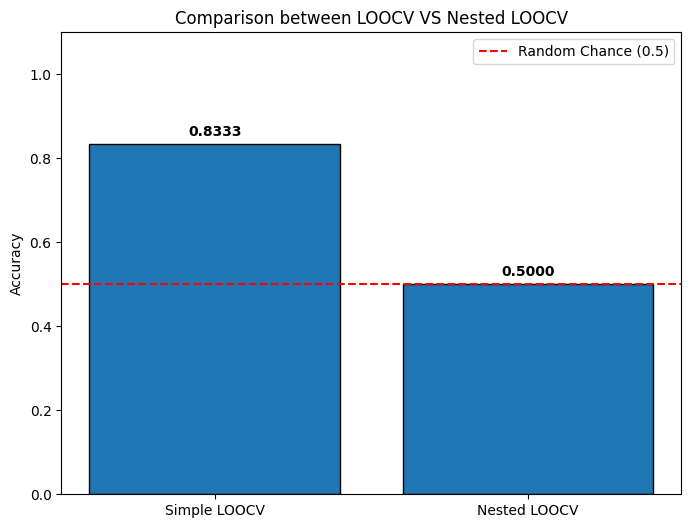

In [6]:
# Why are the results as they are? Why is the nested cross-validation needed?
# Import matplotlib if not already imported
results = {
    'Simple LOOCV': opt_accuracy,
    'Nested LOOCV': np.mean(outer_predictions) 
}
#plot
names = list(results.keys())
values = list(results.values())

plt.figure(figsize=(8, 6))
plt.bar(names, values, edgecolor='black')
plt.axhline(y=0.5, color='red', linestyle='--', label='Random Chance (0.5)')
plt.ylabel('Accuracy')
plt.title('Comparison between LOOCV VS Nested LOOCV')
plt.ylim(0, 1.1)
plt.legend()

for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')

plt.show()

As all of the features were following the bernouli distribution, they have no dependecy to the labels. It is like a 50-50 coin flip. In the LOOCV in the first implementation, the model is picking up pattern from random noise which actually does not exist. So in this case, the best possible accuracy is 50%, which is random guessing.

For greedy forward selection, even with this kind of random data, some features are selected because they correlate by chance woth the labels. However this type of correlation is not correct. When I am using the same data for both feature selection and evaluation, I am getting a very high accuracy of 83%. This is not a proper evaluation of the models performance.

This is were the nested CV is so good. as it made sure that the feature selection is done only on training data. This is where te accuracy drops to 50% as this dataset is random data.

### AI usage

#In case AI was used when solving the exercise, please explain how and in which parts it was used.

I did not need to use AI for this exercise. but i did ask ai to explain the winners curse to me. I also tried to summarize a paper on this topic so that I could understand the concept better. I think my understanding is clear now. 